In [1]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *

In [2]:
name = "strip_gap_radiation"
save_mesh_folder = 'data/gmsh_files/'

path = setup_save_file_paths(name, save_mesh_folder)

In [3]:
mm = 1e-3
width = 50  * mm
length = 2000 * mm
# feed_point = np.array([0, length / 5, 0])
feed_point = np.array([0, 0, 0])

In [4]:
light_speed = 3e8

frequency = 75e6
wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

wavelength = 4.0 Meter


In [5]:
initial_mesh_size = 0.5
# initial_mesh_size = wavelength / 30
print(f"initial_mesh_size = {initial_mesh_size}")

gmsh.initialize()
model_name  = "strip_antenna"

print(f"Longueur: {width} m, Hauteur: {length} m")

# Model creation
gmsh.model.add(model_name)
setup_performance_config()

strip_antenna = gmsh.model.occ.addRectangle(-width / 2, -length / 2, 0, width, length) 

# synchronize after embedding
gmsh.model.occ.synchronize()

generate_and_save_mesh(path.geo, path.msh, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

initial_mesh_size = 0.5
Longueur: 0.05 m, Hauteur: 2.0 m
[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/strip_gap_radiation.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/strip_gap_radiation.msh successfully


In [6]:
extract_msh_to_mat(path.msh, path.mat)

if new_feed: matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, voltage_amplitude=1, port_type=0)
else: pass

In [7]:
matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, excitation_unit_vector='y')

Current at feed edge (index 6): 2.3433e-01-4.8062e-02j A
Length of feed edge: 5.0000e-02 m
Calculated Gap Current: 1.1716e-02-2.4031e-03j A | 1.1716e+01-2.4031e+00j mA
Calculated Input Impedance at the feed point: 8.1905e+01+1.6800e+01j Ohms
Calculated Active Power delivered to the antenna: 5.8581e-03 W
Maximum Surface Current Density : 0.23949868325588627 (A/m)


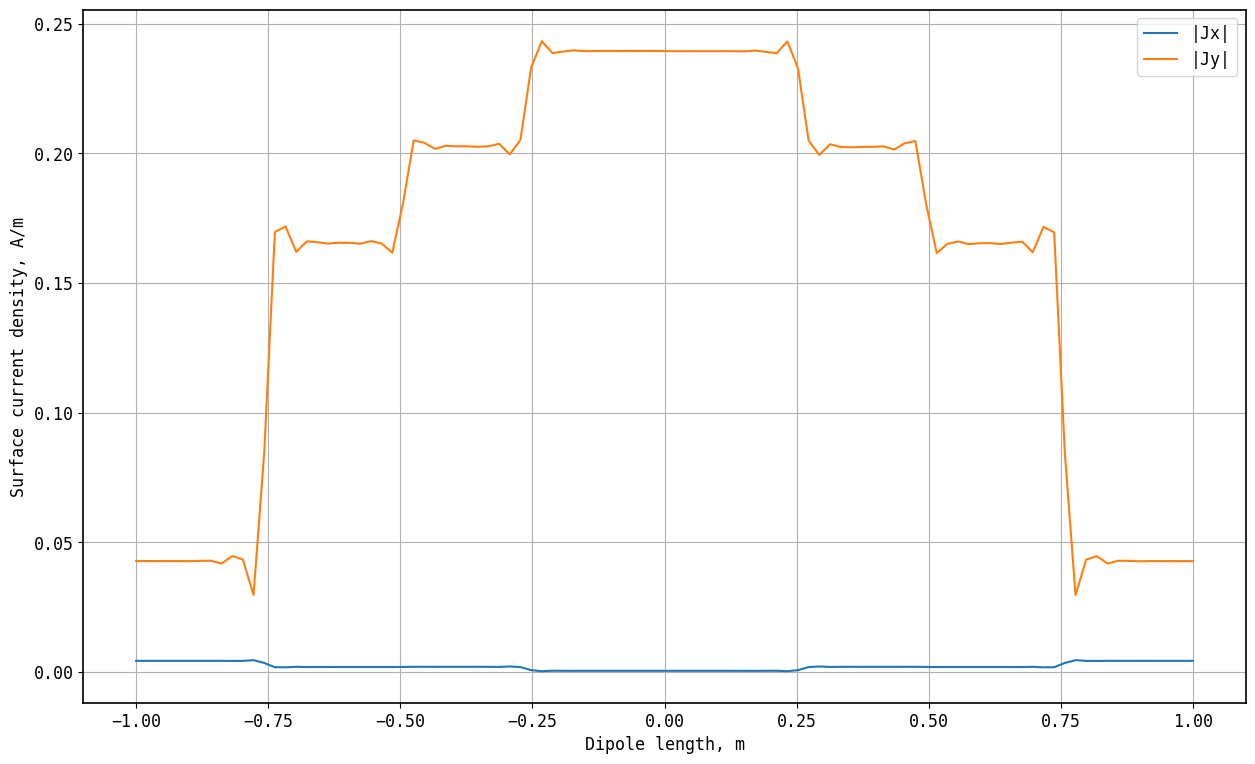

In [8]:
from backend.rwg.rwg6 import plot_surface_current_distribution

filename_mesh_2 = "data/antennas_mesh2/strip_gap_radiation_mesh2.mat"
filename_current = "data/antennas_current/strip_gap_radiation_current.mat"

plot_surface_current_distribution(filename_mesh_2, filename_current, radiation=True)